In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
data = {  # data নামে একটি ডিকশনারি তৈরি করা হয়েছে যাতে পিৎজার সাইজ এবং দাম আছে

    "size": [6, 8, 12, 14, 18], # পিৎজার আকার
    "price": [350, 775, 1150, 1395, 1675] # পিৎজার দাম
}
df = pd.DataFrame(data) # ডেটাকে প্যান্ডাস ডেটাফ্রেমে রূপান্তর করে

x = df['size'].values # x এ সাইজের ভ্যালুগুলো numpy array আকারে নেওয়া হয়েছে (independent variable)
y = df['price'].values # y এ দামের ভ্যালুগুলো numpy array আকারে নেওয়া হয়েছে (dependent variable)




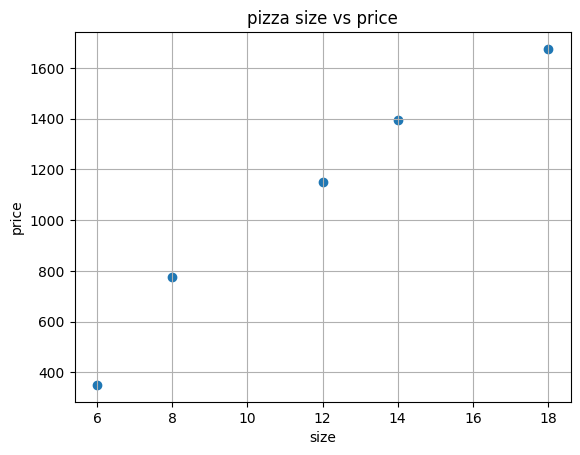

In [10]:
plt.scatter(x, y) # x এবং y এর মধ্যে scatter plot তৈরি করে
plt.title("pizza size vs price")
plt.xlabel('size') # x-অক্ষের লেবেল সেট করে (সাইজ)
plt.ylabel('price')
plt.grid(True) #***  গ্রিড লাইন দেখায়
plt.show()

In [25]:
#Initialize parameters
w_0 = 0.0  #** intercept (y = w₁x + w₀ এ w₀)
w_1 = 0.0 #**  slope (y = w₁x + w₀ এ w₁)
learning_rate = 0.01 # গ্রেডিয়েন্ট ডিসেন্টের লার্নিং রেট, কত দ্রুত মডেল শিখবে তা নির্ধারণ করে
epochs = 100 # কতবার অ্যালগরিদম পুনরাবৃত্তি হবে
n = len(x) # ডেটা পয়েন্টের সংখ্যা (এখানে 5)
w_0_history = []
w_1_history = [] # প্রতি epoch-এ w₀ এবং w₁ এর মান সংরক্ষণের জন্য খালি লিস্ট
cost_history = [] # প্রতি epoch-এ cost (error) সংরক্ষণের জন্য খালি লিস্ট

In [36]:
# Gradient Descent Algorithm
for i in range(epochs+1): # লুপ 0 থেকে 100 পর্যন্ত চলবে (মোট 101 বার)
  y_pred = w_1 * x + w_0 # (লিনিয়ার রিগ্রেশন সমীকরণ)
cost = (1/(2*n))*np.sum((y_pred - y)**2)  # Mean Squared Error (MSE) এর অর্ধেক
dw_1 = (1/n) * np.sum((y_pred - y)*x) # dw_1 = w₁ এর সাপেক্ষে cost function এর derivative (gradient)
dw_0 = (1/n) * np.sum(y_pred - y) # dw_0 = w₀ এর সাপেক্ষে cost function এর derivative
w_1 = w_1 - learning_rate * dw_1
"""
- গ্রেডিয়েন্ট ডিসেন্ট আপডেট রুল: নতুন weight = পুরনো weight - learning_rate × gradient
- gradient নেগেটিভ হলে weight বাড়ে, পজিটিভ হলে weight কমে
- লক্ষ্য হল cost কমানো
"""
w_0 = w_0 - learning_rate * dw_0

w_1_history.append(w_1)
w_0_history.append(w_0)
cost_history.append(cost)
"""
- প্রতি epoch-এ w₁, w₀ এবং cost এর হিস্টোরি সেভ করা
- পরে visualization এবং analysis এর জন্য ব্যবহার করা হবে
"""




'\n- প্রতি epoch-এ w₁, w₀ এবং cost এর হিস্টোরি সেভ করা\n- পরে visualization এবং analysis এর জন্য ব্যবহার করা হবে\n'

/tmp/ipykernel_3803/657032295.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


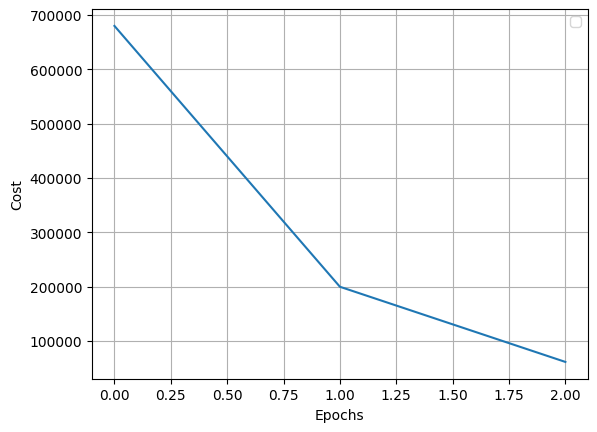

In [33]:
#  কস্ট ভিজুয়ালাইজেশন
plt.plot(cost_history) # epoch অনুযায়ী cost এর পরিবর্তন plot করে
plt.xlabel("Epochs") # x-অক্ষে Epochs (iteration সংখ্যা)
plt.ylabel("Cost") # y-অক্ষে Cost (error)
plt.legend()  # cost কমতে থাকলে বুঝা যায় মডেল ঠিকভাবে শিখছে
plt.grid(True)
plt.show()

In [37]:
#R squred [Performance]
up = y_pred - np.mean(y) #  মডেলের predicted values
down = y - np.mean(y) # actual values এর গড়
up=up**2 #  predicted value এবং actual গড়ের পার্থক্য (regression sum of squares)
down=down**2 #  actual value এবং actual গড়ের পার্থক্য (total sum of squares)
r_sq = np.sum(up)/np.sum(down) # explained variance / total variance
print(r_sq*100)  # শতকরা আকারে R-squared

114.69639055666327


In [38]:
"""
সারসংক্ষেপ
এই কোডটি:

পিৎজার সাইজ এবং দামের ডেটা নিয়ে

লিনিয়ার রিগ্রেশন মডেল তৈরি করে

গ্রেডিয়েন্ট ডিসেন্ট ব্যবহার করে মডেল ট্রেনিং করে

কস্ট কমানোর প্রক্রিয়া দেখায়

R-squared এর মাধ্যমে মডেলের পারফরম্যান্স মূল্যায়ন করে
"""

'\nসারসংক্ষেপ\nএই কোডটি:\n\nপিৎজার সাইজ এবং দামের ডেটা নিয়ে\n\nলিনিয়ার রিগ্রেশন মডেল তৈরি করে\n\nগ্রেডিয়েন্ট ডিসেন্ট ব্যবহার করে মডেল ট্রেনিং করে\n\nকস্ট কমানোর প্রক্রিয়া দেখায়\n\nR-squared এর মাধ্যমে মডেলের পারফরম্যান্স মূল্যায়ন করে\n'